# Predictive Analytics Using Historical Data

Building a predictive model to **forecast future revenue trends** from historical monthly sales data.

**Approach:** Load historical data → clean & preprocess it → engineer features (trend + seasonality) → train two different forecasting approaches (Linear Regression and Holt-Winters Exponential Smoothing) → evaluate accuracy on held-out data → forecast the next 6 months.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


## 2. Load the Data

36 months (Jan 2023 – Dec 2025) of historical revenue data. Like most real-world datasets, it isn't perfectly clean — it has a few missing months and a data-entry outlier that need to be handled before modeling.


In [2]:
df = pd.read_csv("historical_sales.csv", parse_dates=["Month"])
df = df.sort_values("Month").reset_index(drop=True)
print(df.shape)
df.head(10)


(36, 2)


,Month,Revenue
0,2023-01-01,NaN
1,2023-02-01,378897.0
2,2023-03-01,423861.0
3,2023-04-01,445949.0
4,2023-05-01,495776.0
5,2023-06-01,480995.0
6,2023-07-01,1735468.8
7,2023-08-01,583505.0
8,2023-09-01,597123.0
9,2023-10-01,678774.0


In [3]:
print("Missing values:", df['Revenue'].isna().sum())
df.describe()


Missing values: 3


,Month,Revenue
count,36,3.300000e+01
mean,2024-06-16 02:40:00,7.670276e+05
min,2023-01-01 00:00:00,3.788970e+05
25%,2023-09-23 12:00:00,5.842690e+05
50%,2024-06-16 00:00:00,6.787740e+05
75%,2025-03-08 18:00:00,8.809130e+05
max,2025-12-01 00:00:00,1.735469e+06
std,NaN,2.934511e+05


## 3. Data Cleaning & Preprocessing

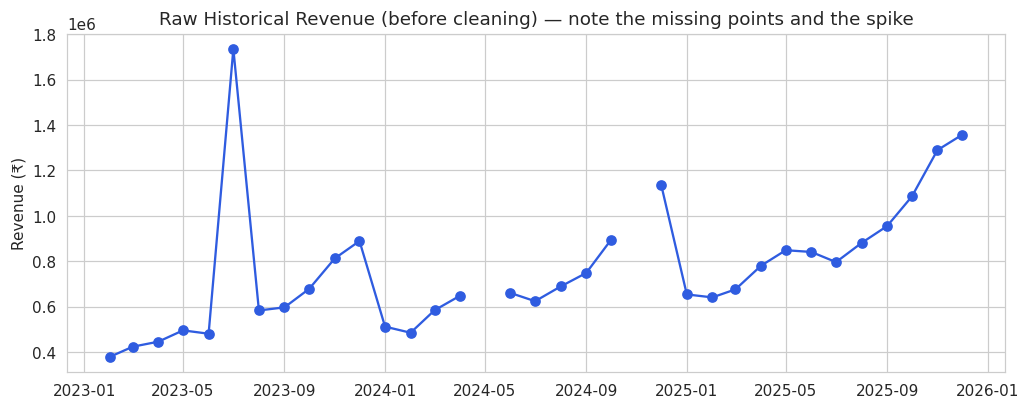

In [4]:
plt.figure(figsize=(11, 4))
plt.plot(df["Month"], df["Revenue"], marker="o", color="#2F5CE0")
plt.title("Raw Historical Revenue (before cleaning) — note the missing points and the spike")
plt.ylabel("Revenue (₹)")
plt.savefig("plots/01_raw_data.png", bbox_inches="tight")
plt.show()


**Cleaning steps applied:**
1. **Missing values** — filled using time-based linear interpolation (reasonable for a smooth monthly trend)
2. **Outlier detection** — flagged any point more than 2.5 standard deviations from a rolling median, then treated it the same way as a missing value and interpolated


In [5]:
df_clean = df.copy()

# Step 1: interpolate missing values along the time axis
# limit_direction="both" also handles missing values at the very start/end of the series
df_clean["Revenue"] = df_clean["Revenue"].interpolate(method="linear", limit_direction="both")

# Step 2: outlier detection using rolling median + deviation threshold
rolling_median = df_clean["Revenue"].rolling(window=5, center=True, min_periods=1).median()
deviation = (df_clean["Revenue"] - rolling_median).abs()
threshold = 2.5 * deviation.std()
outliers = deviation > threshold
print(f"Outliers detected: {outliers.sum()}")
df_clean.loc[outliers, "Month"]


Outliers detected: 1


6   2023-07-01
Name: Month, dtype: datetime64[us]

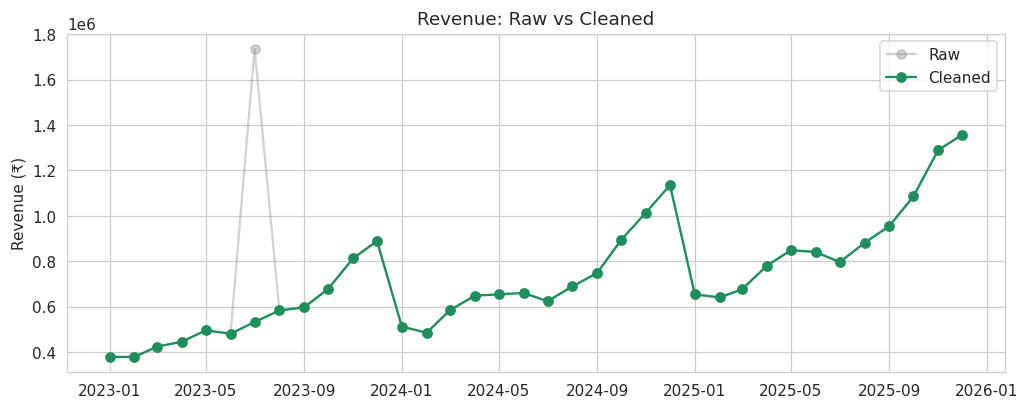

In [6]:
# Treat outliers as missing, then interpolate again
df_clean.loc[outliers, "Revenue"] = np.nan
df_clean["Revenue"] = df_clean["Revenue"].interpolate(method="linear", limit_direction="both")

plt.figure(figsize=(11, 4))
plt.plot(df["Month"], df["Revenue"], marker="o", alpha=0.35, color="grey", label="Raw")
plt.plot(df_clean["Month"], df_clean["Revenue"], marker="o", color="#1E8E5A", label="Cleaned")
plt.title("Revenue: Raw vs Cleaned")
plt.ylabel("Revenue (₹)")
plt.legend()
plt.savefig("plots/02_cleaned_data.png", bbox_inches="tight")
plt.show()


## 4. Feature Engineering

For the regression model, historical time-series values need to be converted into numeric features:
- **Time_Index** — a simple month counter, to capture the overall upward trend
- **Month_Sin / Month_Cos** — cyclical encoding of the calendar month, to capture yearly seasonality (this handles the fact that December and January are "close" in seasonal terms, which a plain month number 1–12 wouldn't capture)


In [7]:
df_clean["Time_Index"] = np.arange(len(df_clean))
df_clean["Month_Num"] = df_clean["Month"].dt.month
df_clean["Month_Sin"] = np.sin(2 * np.pi * df_clean["Month_Num"] / 12)
df_clean["Month_Cos"] = np.cos(2 * np.pi * df_clean["Month_Num"] / 12)
df_clean.head()


,Month,Revenue,Time_Index,Month_Num,Month_Sin,Month_Cos
0,2023-01-01,378897.0,0,1,0.500000,8.660254e-01
1,2023-02-01,378897.0,1,2,0.866025,5.000000e-01
2,2023-03-01,423861.0,2,3,1.000000,6.123234e-17
3,2023-04-01,445949.0,3,4,0.866025,-5.000000e-01
4,2023-05-01,495776.0,4,5,0.500000,-8.660254e-01


## 5. Train / Test Split

Since this is time-series data, we **cannot randomly shuffle** the split (that would leak future information into training). Instead, the most recent 6 months are held out as the test set, and the model is trained only on data that came before it — mimicking how the model would actually be used in production.


In [8]:
test_size = 6
train = df_clean.iloc[:-test_size].reset_index(drop=True)
test = df_clean.iloc[-test_size:].reset_index(drop=True)
print(f"Train: {len(train)} months | Test: {len(test)} months")
print("Test period:", test['Month'].min().date(), "to", test['Month'].max().date())


Train: 30 months | Test: 6 months
Test period: 2025-07-01 to 2025-12-01


## 6. Model 1 — Linear Regression (Trend + Seasonality)

In [9]:
feature_cols = ["Time_Index", "Month_Sin", "Month_Cos"]
X_train, y_train = train[feature_cols], train["Revenue"]
X_test, y_test = test[feature_cols], test["Revenue"]

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_pred = np.clip(lr_pred, 0, None)
test["LR_Pred"] = lr_pred
test[["Month", "Revenue", "LR_Pred"]]


,Month,Revenue,LR_Pred
0,2025-07-01,796389.0,8.948964e+05
1,2025-08-01,880913.0,9.677762e+05
2,2025-09-01,955251.0,1.027623e+06
3,2025-10-01,1085493.0,1.062390e+06
4,2025-11-01,1289737.0,1.066748e+06
5,2025-12-01,1357312.0,1.043520e+06


## 7. Model 2 — Holt-Winters Exponential Smoothing (Time-Series)

Holt-Winters is a classical time-series method that explicitly models three components: **level**, **trend**, and **seasonality** — well suited to monthly sales data with a yearly seasonal cycle.


In [10]:
hw_model = ExponentialSmoothing(
    train["Revenue"], trend="add", seasonal="add", seasonal_periods=12
).fit()

hw_pred = hw_model.forecast(test_size)
test["HW_Pred"] = hw_pred.values
test[["Month", "Revenue", "LR_Pred", "HW_Pred"]]


,Month,Revenue,LR_Pred,HW_Pred
0,2025-07-01,796389.0,8.948964e+05,8.496268e+05
1,2025-08-01,880913.0,9.677762e+05,9.078338e+05
2,2025-09-01,955251.0,1.027623e+06,9.327006e+05
3,2025-10-01,1085493.0,1.062390e+06,1.030445e+06
4,2025-11-01,1289737.0,1.066748e+06,1.148855e+06
5,2025-12-01,1357312.0,1.043520e+06,1.245348e+06


## 8. Model Evaluation

Three standard forecasting accuracy metrics:
- **MAE** (Mean Absolute Error) — average absolute prediction error, in ₹
- **RMSE** (Root Mean Squared Error) — penalizes large errors more heavily
- **MAPE** (Mean Absolute Percentage Error) — error as a % of actual value, easy to interpret across scales


In [11]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"Model": name, "MAE": round(mae, 0), "RMSE": round(rmse, 0), "MAPE (%)": round(mape, 2)}

results = pd.DataFrame([
    evaluate(test["Revenue"], test["LR_Pred"], "Linear Regression"),
    evaluate(test["Revenue"], test["HW_Pred"], "Holt-Winters (Time Series)"),
])
results


,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,136271.0,168923.0,12.06
1,Holt-Winters (Time Series),68434.0,81119.0,6.06


## 9. Visualizing Actual vs Predicted (Test Period)

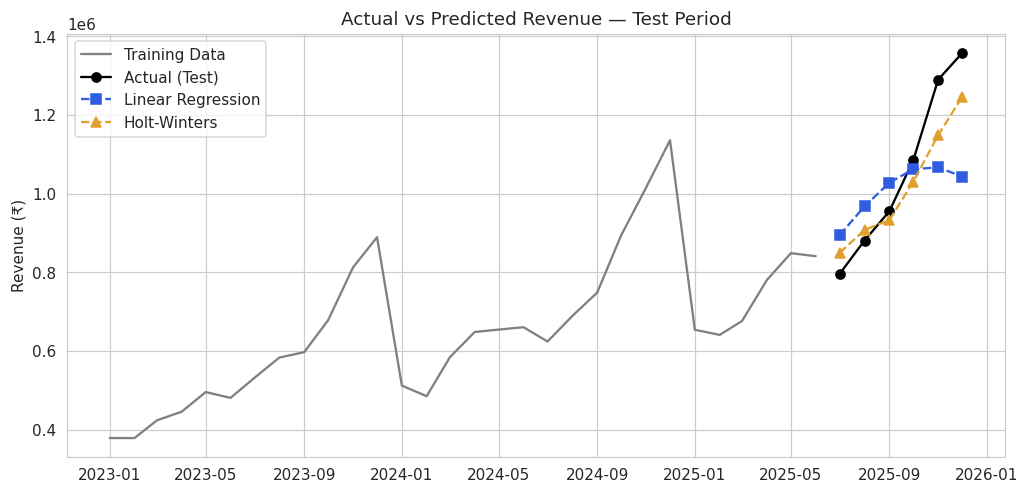

In [12]:
plt.figure(figsize=(11, 5))
plt.plot(train["Month"], train["Revenue"], color="grey", label="Training Data")
plt.plot(test["Month"], test["Revenue"], color="black", marker="o", label="Actual (Test)")
plt.plot(test["Month"], test["LR_Pred"], color="#2F5CE0", marker="s", linestyle="--", label="Linear Regression")
plt.plot(test["Month"], test["HW_Pred"], color="#E0A02F", marker="^", linestyle="--", label="Holt-Winters")
plt.title("Actual vs Predicted Revenue — Test Period")
plt.ylabel("Revenue (₹)")
plt.legend()
plt.savefig("plots/03_actual_vs_predicted.png", bbox_inches="tight")
plt.show()


## 10. Forecasting the Next 6 Months

Based on the evaluation above, we select the **better-performing model** (lower MAPE) and refit it on the **full cleaned dataset** to forecast beyond the available data.


In [13]:
best_model_name = results.loc[results["MAPE (%)"].idxmin(), "Model"]
print(f"Best model selected: {best_model_name}")

future_periods = 6
future_months = pd.date_range(df_clean["Month"].max() + pd.DateOffset(months=1), periods=future_periods, freq="MS")

if best_model_name == "Linear Regression":
    full_time_index = np.arange(len(df_clean), len(df_clean) + future_periods)
    future_month_num = future_months.month
    future_X = pd.DataFrame({
        "Time_Index": full_time_index,
        "Month_Sin": np.sin(2 * np.pi * future_month_num / 12),
        "Month_Cos": np.cos(2 * np.pi * future_month_num / 12),
    })
    lr_full = LinearRegression().fit(df_clean[feature_cols], df_clean["Revenue"])
    forecast_values = np.clip(lr_full.predict(future_X), 0, None)
else:
    hw_full = ExponentialSmoothing(
        df_clean["Revenue"], trend="add", seasonal="add", seasonal_periods=12
    ).fit()
    forecast_values = hw_full.forecast(future_periods).values

forecast_df = pd.DataFrame({"Month": future_months, "Forecast_Revenue": forecast_values.round(0)})
forecast_df


Best model selected: Holt-Winters (Time Series)


,Month,Forecast_Revenue
0,2026-01-01,932925.0
1,2026-02-01,924505.0
2,2026-03-01,995533.0
3,2026-04-01,1075423.0
4,2026-05-01,1117948.0
5,2026-06-01,1115795.0


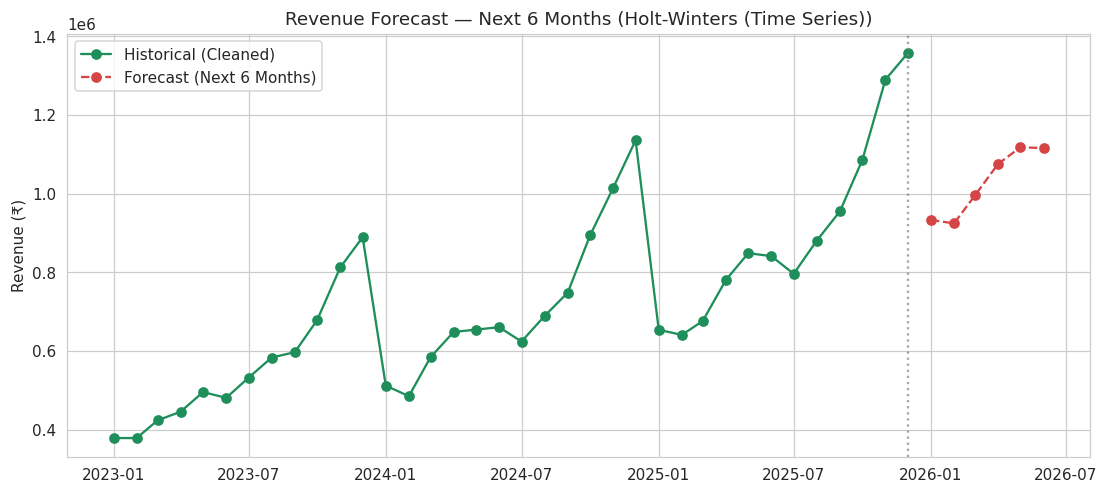

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df_clean["Month"], df_clean["Revenue"], color="#1E8E5A", marker="o", label="Historical (Cleaned)")
plt.plot(forecast_df["Month"], forecast_df["Forecast_Revenue"], color="#D64545", marker="o", linestyle="--", label="Forecast (Next 6 Months)")
plt.axvline(df_clean["Month"].max(), color="grey", linestyle=":", alpha=0.7)
plt.title(f"Revenue Forecast — Next {future_periods} Months ({best_model_name})")
plt.ylabel("Revenue (₹)")
plt.legend()
plt.savefig("plots/04_forecast.png", bbox_inches="tight")
plt.show()


## 11. Save Outputs

In [15]:
output = pd.concat([
    df_clean[["Month", "Revenue"]].assign(Type="Historical"),
    forecast_df.rename(columns={"Forecast_Revenue": "Revenue"}).assign(Type="Forecast")
], ignore_index=True)
output.to_csv("forecast_output.csv", index=False)
results.to_csv("model_evaluation_results.csv", index=False)
print("Saved: forecast_output.csv, model_evaluation_results.csv")
output.tail(10)


Saved: forecast_output.csv, model_evaluation_results.csv


,Month,Revenue,Type
32,2025-09-01,955251.0,Historical
33,2025-10-01,1085493.0,Historical
34,2025-11-01,1289737.0,Historical
35,2025-12-01,1357312.0,Historical
36,2026-01-01,932925.0,Forecast
37,2026-02-01,924505.0,Forecast
38,2026-03-01,995533.0,Forecast
39,2026-04-01,1075423.0,Forecast
40,2026-05-01,1117948.0,Forecast
41,2026-06-01,1115795.0,Forecast


### Summary

- Historical revenue data was cleaned (missing values interpolated, one outlier detected and corrected)
- Two forecasting approaches were built and compared: **Linear Regression** (trend + cyclical seasonality features) and **Holt-Winters Exponential Smoothing** (a dedicated time-series method)
- The model with the lower MAPE on the held-out 6-month test period was selected and used to forecast the next 6 months
- Results show a continuation of the existing upward trend with the same yearly seasonal pattern (dip in Jan/Feb, peak around Oct–Dec)
